## Working with Maidenhead in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/17_maidenhead.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/17_maidenhead.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/17_maidenhead.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://demo.gishub.vn/lab/index.html?path=notebooks/vgrid/17_maidenhead.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2maidenhead

In [7]:
from vgrid.conversion.latlon2dggs import latlon2maidenhead

lat = 10.775276
lon = 106.706797
res = 4
maidenhead_id = latlon2maidenhead(lat, lon, res)
maidenhead_id

'OK30is46'

### Maidenhead to Polygon

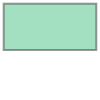

In [3]:
from vgrid.conversion.dggs2geo.maidenhead2geo import maidenhead2geo

maidenhead_geo = maidenhead2geo(maidenhead_id)
maidenhead_geo

### Maidenhead to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.maidenhead2geo import maidenhead2geojson

maidenhead_geojson = maidenhead2geojson(maidenhead_id)
# maidenhead_geojson

### Vector to Maindenhead

d:\Github\vgrid\.venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option COMPACT
  return ogr_read(
Processing features: 100%|██████████| 4/4 [00:00<00:00, 387.81it/s]


<Axes: >

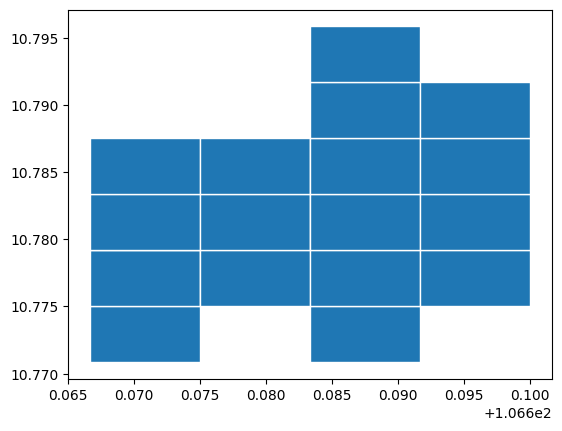

In [1]:
from vgrid.conversion.vector2dggs.vector2maidenhead import vector2maidenhead

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon.geojson"
vector_to_maidenhead = vector2maidenhead(
    file_path,
    resolution=4,
    compact=False,
    topology=False,
    predicate="intersects",
    output_format="gpd",
)
# Visualize the output
# vector_to_georef
vector_to_maidenhead.plot(edgecolor="white")

### Maidenhead Binning

Generating Maidenhead DGGS: 100%|██████████| 27572/27572 [00:04<00:00, 6185.31it/s]


<Axes: >

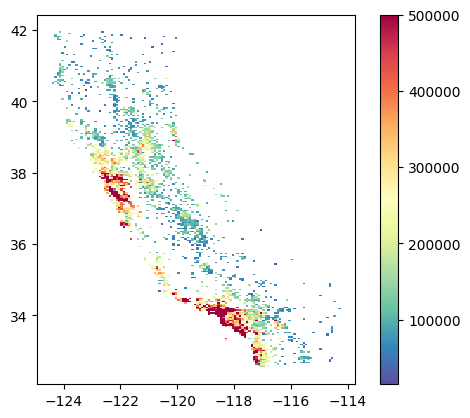

In [2]:
from vgrid.binning.maidenheadbin import maidenheadbin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
stats = "max"
maidenhead_bin = maidenheadbin(
    file_path,
    resolution=3,
    stats=stats,
    numeric_col="median_house_value",
    # category_col="category",
    output_format="gpd",
)
maidenhead_bin.plot(
    column=stats,  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to Maidenhead

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


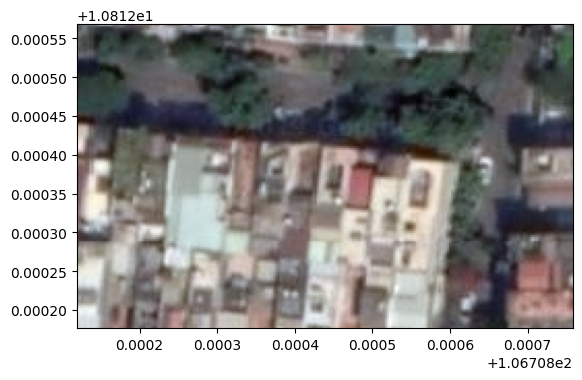

<Axes: >

In [1]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to GARS


In [ ]:
# %pip install folium

In [2]:
from vgrid.conversion.raster2dggs.raster2maidenhead import raster2maidenhead

raster_to_maidenhead = raster2maidenhead(raster_file, resolution = 2, stats = 'mean', output_format="gpd")

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

maidenhead_layer = folium.GeoJson(
    raster_to_maidenhead,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["maidenhead", "band_1", "band_2", "band_3"],
        aliases=["Maidenhead ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(maidenhead_layer.get_bounds())

# Display the map
m

Converting raster to Maidenhead: 100%|██████████| 1/1 [00:00<00:00, 1667.72 cells/s]


### Maidenhead Generator

Generating Maidenhead DGGS:  93%|█████████▎| 30039/32400 [00:07<00:00, 2848.99 cells/s] 

Generating Maidenhead DGGS: 100%|██████████| 32400/32400 [00:09<00:00, 3506.94 cells/s]


<Axes: >

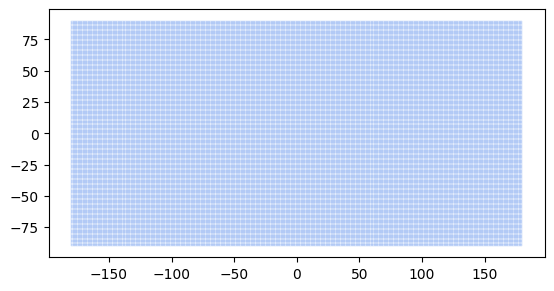

In [5]:
from vgrid.generator.maidenheadgrid import maidenheadgrid

maidenhead_grid = maidenheadgrid(resolution=2, output_format="gpd")
# maidenhead_grid = maidenheadgrid(resolution=3,bbox=[102.14,7.69,114.86,23.39],output_format="gpd")
maidenhead_grid.plot(edgecolor="#3474eb", facecolor="none", linewidth=0.1)

### Maidenhead Inspect

In [1]:
from vgrid.stats.maidenheadstats import maidenheadinspect

resolution = 2
maidenhead_inspect = maidenheadinspect(resolution)
maidenhead_inspect.head()

Generating Maidenhead DGGS: 100%|██████████| 32400/32400 [00:02<00:00, 14660.20 cells/s]


,maidenhead,resolution,center_lat,center_lon,cell_width,cell_height,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,AA00,2,-89.5,-179.0,0.000000,111693.864914,2.176892e+08,227286.185413,"POLYGON ((-180 -90, -178 -90, -178 -89, -180 -...",False,0.013828,0.052954,0.230118,1.0
1,AA01,2,-88.5,-179.0,3898.455585,111693.177216,6.529959e+08,235080.510047,"POLYGON ((-180 -89, -178 -89, -178 -88, -180 -...",False,0.041479,0.148487,0.385339,1.0
2,AA02,2,-87.5,-179.0,7795.700029,111691.802680,1.088088e+09,242869.828017,"POLYGON ((-180 -88, -178 -88, -178 -87, -180 -...",False,0.069117,0.231807,0.481463,1.0
3,AA03,2,-86.5,-179.0,11690.522628,111689.743022,1.522823e+09,250651.722215,"POLYGON ((-180 -87, -178 -87, -178 -86, -180 -...",False,0.096732,0.304592,0.551897,1.0
4,AA04,2,-85.5,-179.0,15581.713544,111687.000814,1.957057e+09,258423.779413,"POLYGON ((-180 -86, -178 -86, -178 -85, -180 -...",False,0.124315,0.368255,0.606839,1.0


### Maidenhead Normalized Area Histogram

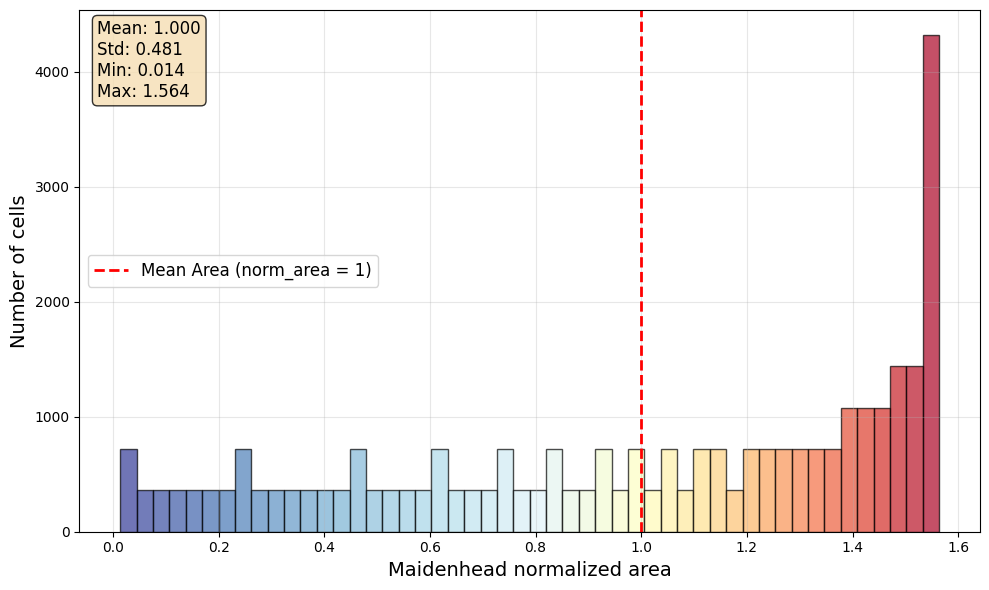

In [2]:
from vgrid.stats.maidenheadstats import maidenhead_norm_area_hist

maidenhead_norm_area_hist(maidenhead_inspect)

### Distribution of Maidenhead Area Distortions

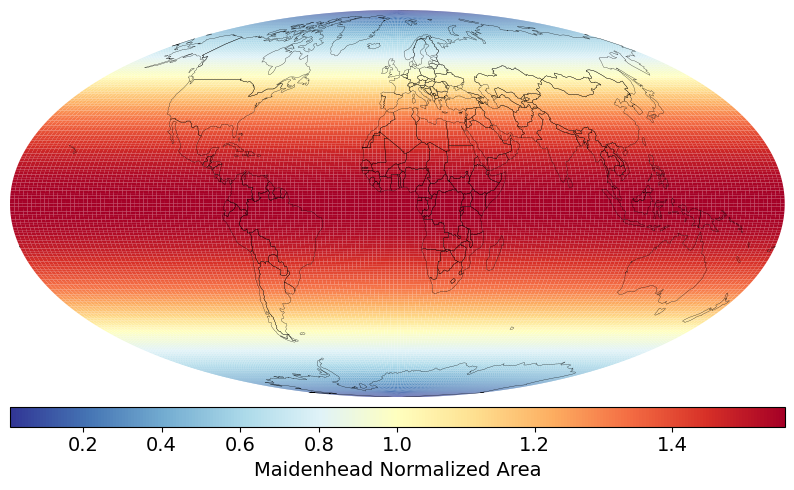

In [3]:
from vgrid.stats.maidenheadstats import maidenhead_norm_area

maidenhead_norm_area(maidenhead_inspect)

### Maidenhead IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is [0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.

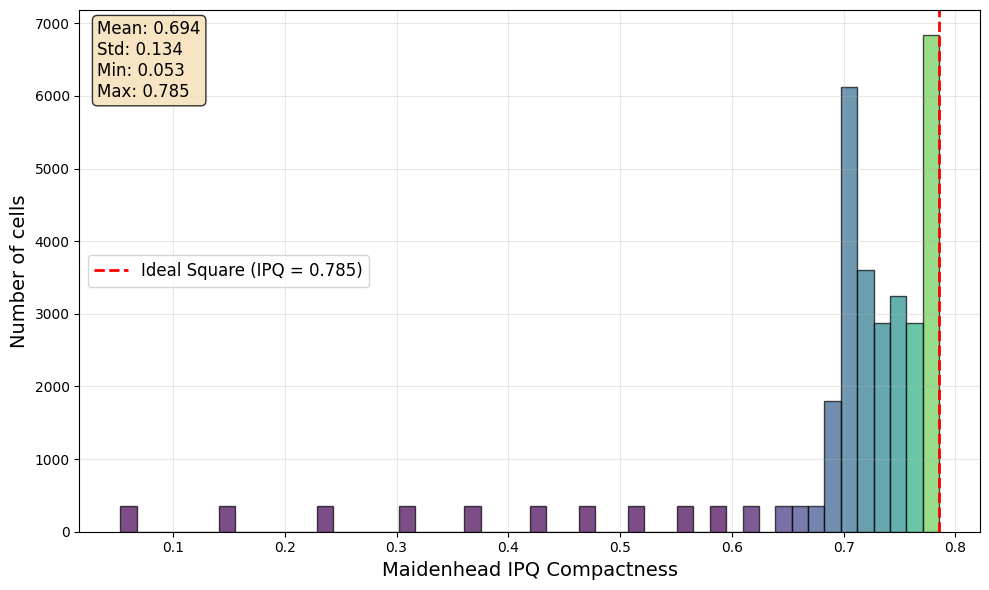

In [4]:
from vgrid.stats.maidenheadstats import maidenhead_compactness_ipq_hist

maidenhead_compactness_ipq_hist(maidenhead_inspect)

### Distribution of Maidenhead IPQ Compactness

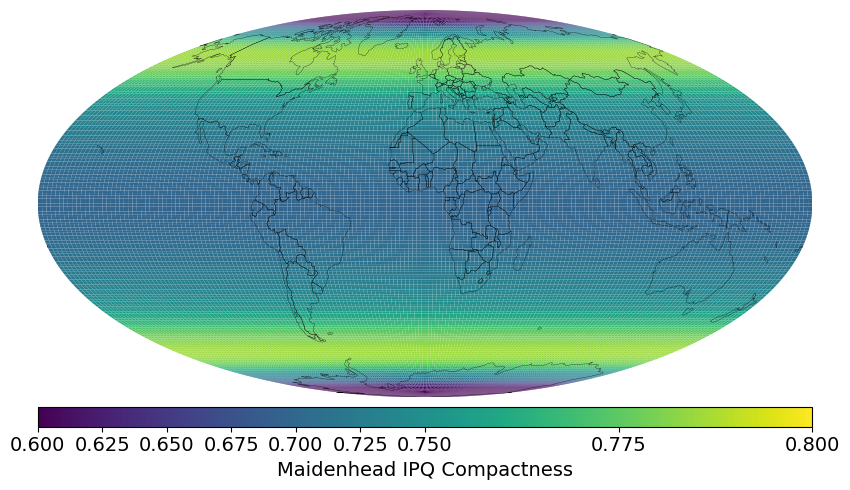

In [7]:
from vgrid.stats.maidenheadstats import maidenhead_compactness_ipq

maidenhead_compactness_ipq(maidenhead_inspect)

### Maidenhead Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is [0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

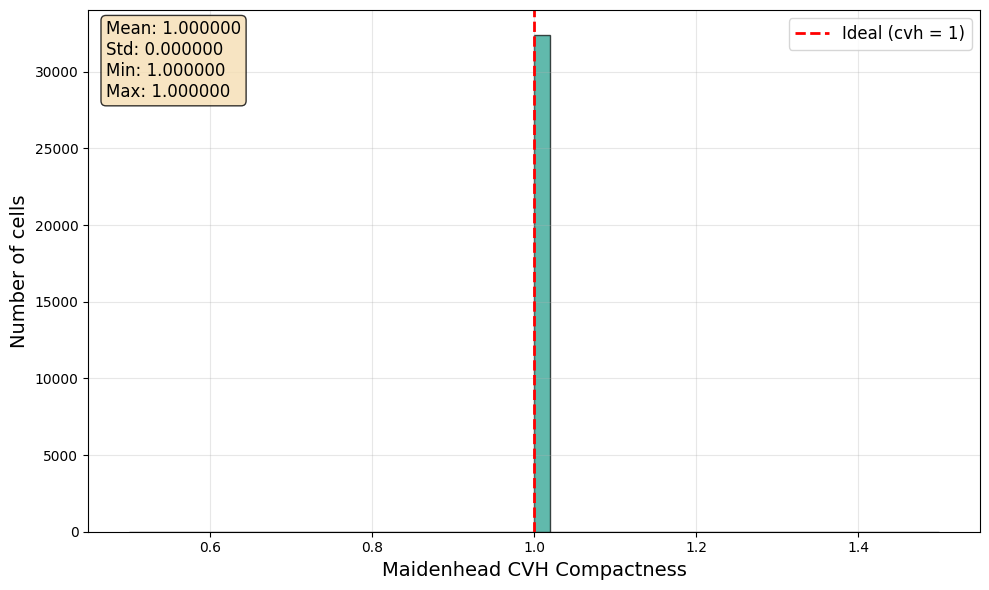

In [8]:
from vgrid.stats.maidenheadstats import maidenhead_compactness_cvh_hist

maidenhead_compactness_cvh_hist(maidenhead_inspect)

### Distribution of Maidenhaed Convex hull Compactness

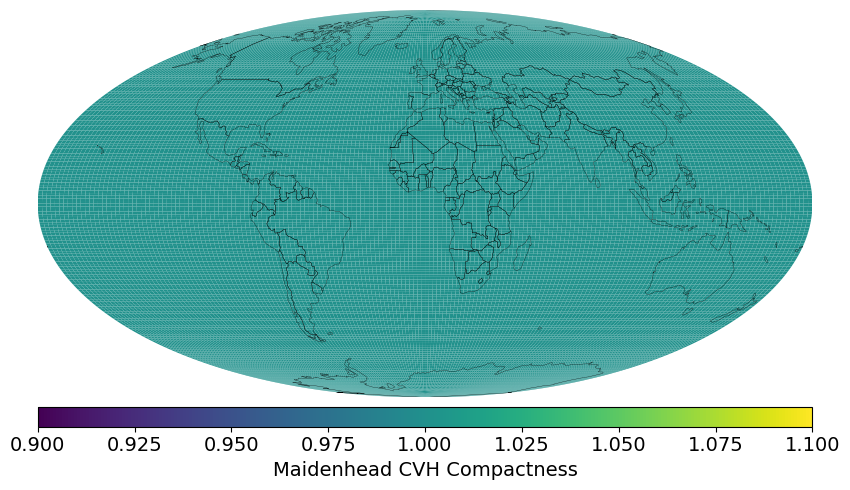

In [9]:
from vgrid.stats.maidenheadstats import maidenhead_compactness_cvh

maidenhead_compactness_cvh(maidenhead_inspect)

### Maidenhead Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [1]:
from vgrid.stats import maidenheadstats

maidenheadstats("km")

,resolution,number_of_cells,avg_edge_len_km,avg_cell_area_km2,cls_km
0,1,324,1254.701801,1.574277e+06,1416.508668
1,2,32400,125.470180,1.574277e+04,141.578666
2,3,18662400,5.227924,2.733119e+01,5.899081
3,4,1866240000,0.522792,2.733119e-01,0.589908
